In [ ]:

import torch
import numpy as np
import pickle
import matplotlib.pyplot as plt
import os


In [2]:
#change work directory
path_project="/home/shij0d/Documents/Dis_Spatial"
os.chdir(path_project)


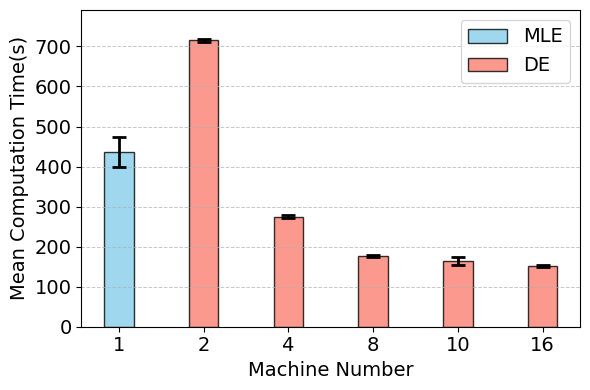

In [3]:
with open(f'real_data/Second_scenario/time_com_varying_J/time_com_varying_J_fixed_N.pkl', 'rb') as f:
        results=pickle.load(f)
Js=[2,4,8,10,16]
R=20
elapsed_times_mle=torch.zeros((len(Js),R),dtype=torch.double)
elapsed_times_de=torch.zeros((len(Js),R),dtype=torch.double)
for j in range(len(Js)):
    for r in range(R):
        elapsed_times_mle[j,r]=results[j][r][0]
        elapsed_times_de[j,r]=results[j][r][1]
elapsed_times_mle=elapsed_times_mle.flatten()
Js = [1,2, 4, 8, 10, 16]
# Assuming elapsed_times_mle and elapsed_times_de are tensors; converted to numpy arrays
# elapsed_times_mle = np.random.rand(5, 20)  # Replace with actual elapsed_times_mle
# elapsed_times_de = np.random.rand(5, 20)   # Replace with actual elapsed_times_de

# Calculate means and standard deviations
mle_mean = np.mean(elapsed_times_mle.numpy())
mle_std = np.std(elapsed_times_mle.numpy())

de_means = np.mean(elapsed_times_de.numpy(), axis=1)
de_std = np.std(elapsed_times_de.numpy(), axis=1)

# Bar plot with error bars
fig, ax = plt.subplots(figsize=(6, 4))  # Increase figure size for better visibility

width = 0.35  # Width of the bars
x = np.arange(len(Js))  # Sample sizes for x axis

# Plot MLE and DE bars with colors and transparency
ax.bar(x[0], mle_mean, width, yerr=mle_std, label='MLE', capsize=5, 
       color='skyblue', edgecolor='black', alpha=0.8, error_kw={'elinewidth': 2, 'capthick': 2})
ax.bar(x[1:], de_means, width, yerr=de_std, label='DE', capsize=5, 
       color='salmon', edgecolor='black', alpha=0.8, error_kw={'elinewidth': 2, 'capthick': 2})
#['skyblue', 'lightgreen']
# Add some text for labels, title, and custom x-axis tick labels
ax.set_xlabel('Machine Number', fontsize=14)
ax.set_ylabel('Mean Computation Time(s)', fontsize=14)
#ax.set_title('Computation Time Comparison Between MLE and DE Methods', fontsize=14)

# Customize x-axis ticks
ax.set_xticks(x)
ax.set_xticklabels(Js, fontsize=14)
ax.legend(fontsize=14)

# Add a light grid to improve readability
ax.grid(True, which='both', axis='y', linestyle='--', linewidth=0.7, alpha=0.7)
ax.tick_params(axis='y', labelsize=14)
# Add y-axis limits for consistency (optional)
ax.set_ylim([0, max(mle_mean + mle_std, max(de_means + de_std)) * 1.1])

# Enhance the layout
plt.tight_layout()

# Show the plot

#plt.savefig("real_data/Second_scenario/time_com_varying_J/time_com_varying_J_fixed_N.pdf")
plt.show()